In [1]:
#==================================================
# Imports
#==================================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
import matplotlib
import os
#import h5py
import PseudoNetCDF as pnc
from scipy.ndimage import label
import scipy.interpolate as interp
import pickle
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.gridspec as gridspec
from scipy.integrate import cumulative_trapezoid as scitrapz

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
#=======================================
# Diagnostics Parameters
#=======================================
space = '    '
#=======================================
# Functions
#=======================================
def print_diag(key,var):
    print(key)
    print(space,'Shape:',np.shape(var))
    print(space,'Max:',np.max(var))
    print(space,'Min:',np.min(var))
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

# Read in Learjet ice cloud pass dictionary

In [3]:
path = '/pscratch/sd/m/mckenna/learjet/20190925/cloud_passes/'
file = path+'camp2ex_learjet_20190925_cloud_pass_dict_ice.p'
learjet_dict = pickle.load(open(file,"rb"))

In [4]:
learjet_dict.keys()

dict_keys(['19', '20', '21', '22', '23'])

In [5]:
path = '/pscratch/sd/m/mckenna/learjet/20190925/cloud_passes/'
file = path+'camp2ex_learjet_20190925_cloud_pass_dict_ice.p'
learjet_dict = pickle.load(open(file,"rb"))


lj_mean_temps = []
lj_min_temps = []
lj_max_temps = []
lj_mean_w = []
lj_std_w = []
lj_max_w = []
lj_min_w = []
lj_keys = []
lj_mean_lwc = []
lj_max_lwc = []
lj_mean_twc = []
lj_max_twc = []
lj_mean_iwc = []
lj_max_iwc = []
lj_transect_length = []
lj_cloud_pass_id = []
lj_mean_alts = []
lj_samp_size = []

for key in learjet_dict.keys():
    tmp_mean_temp = learjet_dict[key]['bulk_dict']['mean_temp']
    tmp_min_temp = learjet_dict[key]['bulk_dict']['min_temp']
    tmp_max_temp = learjet_dict[key]['bulk_dict']['max_temp']
    tmp_mean_w = learjet_dict[key]['bulk_dict']['mean_w']
    tmp_mean_alts = np.mean(learjet_dict[key]['bulk_dict']['alt'])
    tmp_max_w = learjet_dict[key]['bulk_dict']['max_w']
    tmp_min_w = learjet_dict[key]['bulk_dict']['min_w']
    tmp_w = learjet_dict[key]['bulk_dict']['w']
    tmp_std_w = np.std(tmp_w)
    lj_std_w.append(tmp_std_w)
    tmp_mean_lwc = learjet_dict[key]['bulk_dict']['mean_NevLWC']
    tmp_mean_twc = learjet_dict[key]['bulk_dict']['mean_NevTWC']
    tmp_max_lwc = learjet_dict[key]['bulk_dict']['max_NevLWC']
    tmp_max_twc = learjet_dict[key]['bulk_dict']['max_NevTWC']
    tmp_tas = learjet_dict[key]['bulk_dict']['tas'] # m/s
    len_transect = np.sum(tmp_tas)*1.e-3 # since each sample is 1 second, only need to to sum to ket transect length and then convert to km for convenience
    lj_transect_length.append(np.sum(len_transect))
    lj_samp_size.append(len(tmp_tas))
    tmp_lwc = learjet_dict[key]['bulk_dict']['NevLWC']
    tmp_twc = learjet_dict[key]['bulk_dict']['NevTWC']
    tmp_iwc = tmp_twc - tmp_lwc
    tmp_mean_iwc = np.nanmean(tmp_iwc)
    tmp_max_iwc = np.nanmax(tmp_iwc)
    tmp_min_iwc = np.nanmin(tmp_iwc)
    
    lj_mean_temps.append(tmp_mean_temp)
    lj_min_temps.append(tmp_mean_temp)
    lj_max_temps.append(tmp_mean_temp)
    lj_mean_alts.append(tmp_mean_alts)
    lj_mean_w.append(tmp_mean_w)
    lj_std_w.append(tmp_std_w)
    lj_max_w.append(tmp_max_w)
    lj_min_w.append(tmp_min_w)
    lj_mean_lwc.append(tmp_mean_lwc)
    lj_mean_twc.append(tmp_mean_twc)
    lj_mean_iwc.append(tmp_mean_iwc)
    lj_max_lwc.append(tmp_max_lwc)
    lj_max_twc.append(tmp_max_twc)
    lj_max_iwc.append(tmp_max_iwc)
    lj_keys.append(key)
    lj_cloud_pass_id.append(int(key))
    

lj_mean_temps = np.array(lj_mean_temps)
lj_max_temps = np.array(lj_max_temps)
lj_min_temps = np.array(lj_min_temps)
lj_mean_alts = np.array(lj_mean_alts)
lj_mean_w = np.array(lj_mean_w)
lj_max_w = np.array(lj_max_w)
lj_std_w = np.array(lj_std_w)
lj_min_w = np.array(lj_min_w)
lj_mean_lwc = np.array(lj_mean_lwc)
lj_mean_twc = np.array(lj_mean_twc)
lj_mean_iwc = np.array(lj_mean_iwc)
lj_max_lwc = np.array(lj_max_lwc)
lj_max_twc = np.array(lj_max_twc)
lj_max_iwc = np.array(lj_max_iwc)
lj_transect_length = np.array(lj_transect_length)
lj_cloud_pass_id = np.array(lj_cloud_pass_id)
lj_samp_size = np.array(lj_samp_size)

# Read in P3 ice cloud pass dictionary

In [6]:
path = '/pscratch/sd/m/mckenna/p3/20190925/cloud_passes/'
file = path+'camp2ex_p3_20190925_cloud_pass_dict_ice.p'
p3_dict = pickle.load(open(file,"rb"))


p3_mean_temps = []
p3_min_temps = []
p3_max_temps = []
p3_mean_w = []
p3_std_w = []
p3_max_w = []
p3_min_w = []
p3_keys = []
p3_mean_lwc = []
p3_max_lwc = []
p3_mean_twc = []
p3_max_twc = []
p3_mean_iwc = []
p3_max_iwc = []
p3_transect_length = []
p3_cloud_pass_id = []
p3_mean_alts = []
p3_samp_size = []

for i,key in enumerate(p3_dict.keys()):
    if i != 11:
        continue
    tmp_mean_temp = p3_dict[key]['bulk_dict']['mean_temp']
    tmp_min_temp = p3_dict[key]['bulk_dict']['min_temp']
    tmp_max_temp = p3_dict[key]['bulk_dict']['max_temp']
    tmp_mean_w = p3_dict[key]['bulk_dict']['mean_w']
    tmp_mean_alts = np.mean(p3_dict[key]['bulk_dict']['alt'])
    tmp_max_w = p3_dict[key]['bulk_dict']['max_w']
    tmp_min_w = p3_dict[key]['bulk_dict']['min_w']
    tmp_w = p3_dict[key]['bulk_dict']['w']
    tmp_std_w = np.std(tmp_w)
    p3_std_w.append(tmp_std_w)
    #tmp_mean_lwc = p3_dict[key]['bulk_dict']['mean_NevLWC']
    #tmp_mean_twc = p3_dict[key]['bulk_dict']['mean_NevTWC']
    #tmp_max_lwc = p3_dict[key]['bulk_dict']['max_NevLWC']
    #tmp_max_twc = p3_dict[key]['bulk_dict']['max_NevTWC']
    tmp_tas = p3_dict[key]['bulk_dict']['tas'] # m/s
    len_transect = np.sum(tmp_tas)*1.e-3 # since each sample is 1 second, only need to to sum to ket transect length and then convert to km for convenience
    p3_transect_length.append(np.sum(len_transect))
    p3_samp_size.append(len(tmp_tas))
    #tmp_lwc = p3_dict[key]['bulk_dict']['NevLWC']
    #tmp_twc = p3_dict[key]['bulk_dict']['NevTWC']
    tmp_iwc = tmp_twc - tmp_lwc
    tmp_mean_iwc = np.nanmean(tmp_iwc)
    tmp_max_iwc = np.nanmax(tmp_iwc)
    tmp_min_iwc = np.nanmin(tmp_iwc)
    
    p3_mean_temps.append(tmp_mean_temp)
    p3_min_temps.append(tmp_min_temp)
    p3_max_temps.append(tmp_max_temp)
    p3_mean_alts.append(tmp_mean_alts)
    p3_mean_w.append(tmp_mean_w)
    p3_std_w.append(tmp_std_w)
    p3_max_w.append(tmp_max_w)
    p3_min_w.append(tmp_min_w)
    #p3_mean_lwc.append(tmp_mean_lwc)
    #p3_mean_twc.append(tmp_mean_twc)
    #p3_mean_iwc.append(tmp_mean_iwc)
    #p3_max_lwc.append(tmp_max_lwc)
    #p3_max_twc.append(tmp_max_twc)
    #p3_max_iwc.append(tmp_max_iwc)
    p3_keys.append(key)
    p3_cloud_pass_id.append(i)
    

p3_mean_temps = np.array(p3_mean_temps)
p3_max_temps = np.array(p3_max_temps)
p3_min_temps = np.array(p3_min_temps)
p3_mean_alts = np.array(p3_mean_alts)
p3_mean_w = np.array(p3_mean_w)
p3_max_w = np.array(p3_max_w)
p3_std_w = np.array(p3_std_w)
p3_min_w = np.array(p3_min_w)
#p3_mean_lwc = np.array(p3_mean_lwc)
#p3_mean_twc = np.array(p3_mean_twc)
#p3_mean_iwc = np.array(p3_mean_iwc)
#p3_max_lwc = np.array(p3_max_lwc)
#p3_max_twc = np.array(p3_max_twc)
#p3_max_iwc = np.array(p3_max_iwc)
p3_transect_length = np.array(p3_transect_length)
p3_cloud_pass_id = np.array(p3_cloud_pass_id)
p3_samp_size = np.array(p3_samp_size)

In [7]:
# ---------------------------------------------------------------
# Combine LJ (4 passes) and P3 (1 pass) into unified obs_* arrays
# P3 has no LWC/IWC/TWC from the Nevzorov probe → set to NaN
# ---------------------------------------------------------------
n_p3 = len(p3_mean_temps)   # = 1

obs_mean_temps  = np.concatenate([lj_mean_temps,  p3_mean_temps])
obs_min_temps   = np.concatenate([lj_min_temps,   p3_min_temps])
obs_max_temps   = np.concatenate([lj_max_temps,   p3_max_temps])
obs_mean_alts   = np.concatenate([lj_mean_alts,   p3_mean_alts])
obs_mean_w      = np.concatenate([lj_mean_w,      p3_mean_w])
obs_std_w       = np.concatenate([lj_std_w,       p3_std_w])
obs_max_w       = np.concatenate([lj_max_w,       p3_max_w])
obs_min_w       = np.concatenate([lj_min_w,       p3_min_w])
obs_transect_length = np.concatenate([lj_transect_length, p3_transect_length])
obs_samp_size   = np.concatenate([lj_samp_size,   p3_samp_size])

# LWC / IWC / TWC only available from LJ Nevzorov probe
obs_mean_lwc = np.concatenate([lj_mean_lwc, np.full(n_p3, np.nan)])
obs_max_lwc  = np.concatenate([lj_max_lwc,  np.full(n_p3, np.nan)])
obs_mean_twc = np.concatenate([lj_mean_twc, np.full(n_p3, np.nan)])
obs_max_twc  = np.concatenate([lj_max_twc,  np.full(n_p3, np.nan)])
obs_mean_iwc = np.concatenate([lj_mean_iwc, np.full(n_p3, np.nan)])
obs_max_iwc  = np.concatenate([lj_max_iwc,  np.full(n_p3, np.nan)])

# String keys: LJ uses its integer key, P3 uses 'p3'
obs_cloud_pass_keys = [str(x) for x in lj_cloud_pass_id] + ['p3']

# --- Sort all obs arrays from warmest to coldest ---
sort_idx = np.argsort(obs_mean_temps)[::-1]

obs_mean_temps      = obs_mean_temps[sort_idx]
obs_min_temps       = obs_min_temps[sort_idx]
obs_max_temps       = obs_max_temps[sort_idx]
obs_mean_alts       = obs_mean_alts[sort_idx]
obs_mean_w          = obs_mean_w[sort_idx]
obs_std_w           = obs_std_w[sort_idx]
obs_max_w           = obs_max_w[sort_idx]
obs_min_w           = obs_min_w[sort_idx]
obs_transect_length = obs_transect_length[sort_idx]
obs_samp_size       = obs_samp_size[sort_idx]
obs_mean_lwc        = obs_mean_lwc[sort_idx]
obs_max_lwc         = obs_max_lwc[sort_idx]
obs_mean_twc        = obs_mean_twc[sort_idx]
obs_max_twc         = obs_max_twc[sort_idx]
obs_mean_iwc        = obs_mean_iwc[sort_idx]
obs_max_iwc         = obs_max_iwc[sort_idx]
obs_cloud_pass_keys = [obs_cloud_pass_keys[i] for i in sort_idx]

print('Obs cloud pass keys (warm→cold):', obs_cloud_pass_keys)
print('Obs mean temps:', obs_mean_temps)

Obs cloud pass keys (warm→cold): ['19', '21', '20', 'p3', '22', '23']
Obs mean temps: [  1.03636364  -7.275       -7.425      -11.0936     -14.57083333
 -14.75555556]


# Grab the DHARMA CNTL ICE simulation 3D files and grab individual files at 10-minute increments between hours 9 & 12 that emulate the observed cloud passes (i.e., when ice was formed).

In [9]:
#sim_name = 'cntl_bulk_ice_ABIFM'
#title_sim_name = 'Bulk CNTL'

#sim_name = 'cntl_bulk_ice_ABIFM_hm'
#title_sim_name = 'Bulk CNTL HM'

#sim_name = 'sip_bulk_ice_ABIFM'
#title_sim_name = 'Bulk SIP'

#sim_name = 'sip_bulk_ice_ABIFM_hm'
#title_sim_name = 'Bulk SIP HM'

#sim_name = 'sip_10x_bulk_ice_ABIFM'
#title_sim_name = 'Bulk SIP 10X'

sim_name = 'sip_10x_bulk_ice_ABIFM_hm'
title_sim_name = 'Bulk SIP 10X HM'

path = '/pscratch/sd/m/mckenna/dharma_3d/'+sim_name+'/'
files = sorted(glob.glob(path+'dharma_3d*.nc'))
print(len(files))
#print(files)

37


# Read in dictionary that contains parameters needed to reconstruct the bulk simulation DSDs
## These are the gamma distribution parameters for the "cloud" and "rain" hydrometeor species

In [10]:
path2 = '/pscratch/sd/m/mckenna/dharma_3d/psd_params/'
dsd_params_files = sorted(glob.glob(path2+sim_name+'_psd_params_dict_*.p'))
#dsd_params_files = dsd_params_files[18:]
print(len(dsd_params_files))

lam_r = []
lam_c = []
lam_ic = []
lam_if = []
lam_id = []
log_n0_r = []
log_n0_c = []
log_n0_ic = []
log_n0_if = []
log_n0_id = []

for file in dsd_params_files:
    print(file)
    tmp_dict = pickle.load(open(file,"rb"))
    lam_r.append(tmp_dict['lam_r'])
    lam_c.append(tmp_dict['lam_c'])
    lam_ic.append(tmp_dict['lam_ic'])
    lam_if.append(tmp_dict['lam_if'])
    lam_id.append(tmp_dict['lam_id'])
    log_n0_r.append(tmp_dict['log_n0_r'])
    log_n0_c.append(tmp_dict['log_n0_c'])
    log_n0_ic.append(tmp_dict['log_n0_ic'])
    log_n0_if.append(tmp_dict['log_n0_if'])
    log_n0_id.append(tmp_dict['log_n0_id'])
lam_r = np.array(lam_r)
lam_c = np.array(lam_c)
lam_ic = np.array(lam_ic)
lam_if = np.array(lam_if)
lam_id = np.array(lam_id)
log_n0_r = np.array(log_n0_r)
log_n0_c = np.array(log_n0_c)
log_n0_ic = np.array(log_n0_ic)
log_n0_if = np.array(log_n0_if)
log_n0_id = np.array(log_n0_id)

37
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_21600.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_22200.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_22800.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_23400.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_24000.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_24600.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_25200.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_25800.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_26400.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_ice_ABIFM_hm_psd_params_dict_27000.p
/pscratch/sd/m/mckenna/dharma_3d/psd_params/sip_10x_bulk_

In [39]:
#np.unique(lam_if)

# Read in 3D files and construct 4D arrays (added time dimension) of additional variables needed to reconstruct the gamma distributions

In [11]:
time = []
qcloud = []
qrain = []
qice = []
qicef = []
qiced = []
qncloud = []
qnrain = []
qnice = []
qnicef = []
qniced = []
rho = []
w = []
temp = []

dumi=1
for file in files:
    print(file)
    ncfile = xarray.open_dataset(file,decode_times=False)
    time.append(ncfile['time'].values)
    qcloud.append(ncfile['qc'].values)
    qrain.append(ncfile['qr'].values)
    qice.append(ncfile['qic'].values)
    qicef.append(ncfile['qif'].values)
    qiced.append(ncfile['qid'].values)
    qncloud.append(ncfile['nc'].values)
    qnrain.append(ncfile['nr'].values)
    qnice.append(ncfile['nic'].values)
    qnicef.append(ncfile['nif'].values)
    qniced.append(ncfile['nid'].values)
    rho.append(ncfile['rhobar'].values)
    w.append(ncfile['w_interp'].values)
    temp.append(ncfile['temperature'].values-273.15)
    if dumi==1:
        x = ncfile['x'].values
        y = ncfile['y'].values
        z = ncfile['zt'].values
        dumi=0
        
time = np.array(time)
qcloud = np.array(qcloud)
qrain = np.array(qrain)
qice = np.array(qice)
qicef = np.array(qicef)
qiced = np.array(qiced)
qncloud = np.array(qncloud)
qnrain = np.array(qnrain)
qnice = np.array(qnice)
qnicef = np.array(qnicef)
qniced = np.array(qniced)
w = np.array(w)
temp = np.array(temp)
rho = np.array(rho)

clwc = qcloud*rho[0,:]*1.e3
rwc = qrain*rho[0,:]*1.e3
ciwc = qice*rho[0,:]*1.e3
ifwc = qicef*rho[0,:]*1.e3
idwc = qiced*rho[0,:]*1.e3
lwc = clwc + rwc
iwc = ciwc + ifwc + idwc
twc = lwc + iwc
qncloud = qncloud*rho[0,:]*1.e-6
qnrain = qnrain*rho[0,:]*1.e-6
qnice = qnice*rho[0,:]*1.e-6
qnicef = qnicef*rho[0,:]*1.e-6
qniced = qniced*rho[0,:]*1.e-6
qnl = qncloud + qnrain
qni = qnice + qnicef + qniced
qnt = qnl + qni

/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_021600.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_022200.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_022800.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_023400.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_024000.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_024600.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_025200.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_025800.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM_hm/dharma_3d_sip_10x_bulk_ice_ABIFM_hm_026400.nc
/pscratch/sd/m/mckenna/dharma_3d/sip_10x_bulk_ice_ABIFM

# Create functions that make a "cloud pass" dictionary for the CNTL DHARMA simulation
## Loop through 19 times (10-min. increment)  used to be representative
## Pass in the desired temperature, which is chosen based on the mean temperature of the observed cloud pass
## Finds the nearest model level to the target observed temperature
## Cloud passes are defined as contiguous segments of TWC > 0.1 g/m3
## Do this in both the 'x' and 'y' directions, but only the 'y' direction is used for the manuscript--sensitivity testing showed this direction didn't actually matter
## For each cloud pass, save the gamma distribution parameters and statistics of the cloud pass, including the average and maximum vertical velocity, and the cloud pass transect length

In [12]:
if False:
    def make_cloud_pass_dict_y(var_dict,target_obs_temp):
        nx = len(var_dict['x'])
        ny = len(var_dict['y'])
        nt = len(var_dict['lwc'][:,0,0,0])
    
        cloud_pass_dict_y = {}
        cp_counter=1
        
        for tt in range(nt):
            mean_temp_prof = np.mean(var_dict['temp'][tt,:,:,:],axis=(0,1))
            nearest_val,nearest_id = find_nearest(mean_temp_prof,target_obs_temp)
            nearest_z = var_dict['z'][nearest_id]*1.e-3
            print('tt:',tt)
            print(mean_temp_prof[nearest_id-1])
            print(mean_temp_prof[nearest_id])
            print(mean_temp_prof[nearest_id+1])
            print('-------------------------------')
    
            for kkk in range(-1,2,1):
                xxx_id = int(nearest_id + kkk)
                tmp_lwc = var_dict['lwc'][tt,:,:,xxx_id].T
                tmp_iwc = var_dict['iwc'][tt,:,:,xxx_id].T
                tmp_twc = var_dict['twc'][tt,:,:,xxx_id].T
                tmp_w = var_dict['w'][tt,:,:,xxx_id].T
                tmp_nr_liq = var_dict['nr_liq'][tt,:,:,:,xxx_id].T
                tmp_nr_ice = var_dict['nr_ice'][tt,:,:,:,xxx_id].T
                tmp_rho = var_dict['rho'][tt,xxx_id]
        
                vec_mask = np.zeros((nx,ny))
                for ii in range(nx):
                    tmp_vec_mask = np.zeros(nx)
                    dum_lwc = tmp_lwc[ii,:]
                    dum_iwc = tmp_iwc[ii,:]
                    dum_twc = tmp_twc[ii,:]
                    dum_w = tmp_w[ii,:]
                    #dum_nr = tmp_nr[ii,:,:]
                    dum_nr_liq = tmp_nr_liq[ii,:,:]
                    dum_nr_ice = tmp_nr_ice[ii,:,:]
        
                    cloud_id = np.where(dum_twc > 0.1)[0]
                    tmp_vec_mask[cloud_id] = 1
                    vec_mask[ii,:] = tmp_vec_mask
        
                    if np.size(cloud_id) > 0.:
                        labels,numL = label(tmp_vec_mask)
        
                        for dd in range(numL):
                            dumid = np.where(labels == (dd+1))[0]
                            cloud_pass_dict_y[str(cp_counter)] = {}
                            cloud_pass_dict_y[str(cp_counter)]['avg_w'] = np.mean(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_w'] = np.max(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['min_w'] = np.min(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['avg_lwc'] = np.mean(dum_lwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_lwc'] = np.max(dum_lwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['avg_iwc'] = np.mean(dum_iwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_iwc'] = np.max(dum_iwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['avg_twc'] = np.mean(dum_twc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_twc'] = np.max(dum_twc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['lwc'] = dum_lwc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['iwc'] = dum_iwc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['twc'] = dum_twc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['transect_length'] = np.size(dumid)*100.*1.e-3 # km
                            #cloud_pass_dict_y[str(cp_counter)]['nr'] = dum_nr[dumid,:]
                            cloud_pass_dict_y[str(cp_counter)]['nr_liq'] = dum_nr_liq[dumid,:]
                            cloud_pass_dict_y[str(cp_counter)]['nr_ice'] = dum_nr_ice[dumid,:]
                            cloud_pass_dict_y[str(cp_counter)]['rho'] = tmp_rho
        
                            cp_counter+=1
    
        return cloud_pass_dict_y

In [13]:
def make_cloud_pass_dict_y(var_dict,target_lj_temp):
    nx = len(var_dict['x'])
    ny = len(var_dict['y'])
    nt = len(var_dict['lwc'][:,0,0,0])
    
    cloud_pass_dict_y = {}

    cp_counter=1
    for tt in range(nt):
        
        mean_temp_prof = np.mean(var_dict['temp'][tt,:,:,:],axis=(0,1))
        nearest_val,nearest_id = find_nearest(mean_temp_prof,target_lj_temp)
        nearest_z = var_dict['z'][nearest_id]*1.e-3
        print('tt:',tt)
        print(mean_temp_prof[nearest_id-1])
        print(mean_temp_prof[nearest_id])
        print(mean_temp_prof[nearest_id+1])
        print('-------------------------------')

        if nearest_val < 0.:
            for kkk in range(-1,2,1):
                xxx_id = int(nearest_id + kkk)
                
                tmp_lwc = var_dict['lwc'][tt,:,:,xxx_id].T
                tmp_twc = var_dict['twc'][tt,:,:,xxx_id].T
                tmp_iwc = var_dict['iwc'][tt,:,:,xxx_id].T
                tmp_w = var_dict['w'][tt,:,:,xxx_id].T
                tmp_lam_r = var_dict['lam_r'][tt,:,:,xxx_id].T
                tmp_lam_c = var_dict['lam_c'][tt,:,:,xxx_id].T
                tmp_lam_ic = var_dict['lam_ic'][tt,:,:,xxx_id].T
                tmp_lam_if = var_dict['lam_if'][tt,:,:,xxx_id].T
                tmp_lam_id = var_dict['lam_id'][tt,:,:,xxx_id].T
                tmp_log_n0_r = var_dict['log_n0_r'][tt,:,:,xxx_id].T
                tmp_log_n0_c = var_dict['log_n0_c'][tt,:,:,xxx_id].T
                tmp_log_n0_ic = var_dict['log_n0_ic'][tt,:,:,xxx_id].T
                tmp_log_n0_if = var_dict['log_n0_if'][tt,:,:,xxx_id].T
                tmp_log_n0_id = var_dict['log_n0_id'][tt,:,:,xxx_id].T
        
        
                vec_mask = np.zeros((nx,ny))
                for ii in range(nx):
                    tmp_vec_mask = np.zeros(ny)
                    dum_lwc = tmp_lwc[ii,:]
                    dum_twc = tmp_twc[ii,:]
                    dum_iwc = tmp_iwc[ii,:]
                    dum_w = tmp_w[ii,:]
                    dum_lam_r = tmp_lam_r[ii,:]
                    dum_lam_c = tmp_lam_c[ii,:]
                    dum_lam_ic = tmp_lam_ic[ii,:]
                    dum_lam_if = tmp_lam_if[ii,:]
                    dum_lam_id = tmp_lam_id[ii,:]
                    dum_log_n0_r = tmp_log_n0_r[ii,:]
                    dum_log_n0_c = tmp_log_n0_c[ii,:]
                    dum_log_n0_ic = tmp_log_n0_ic[ii,:]
                    dum_log_n0_if = tmp_log_n0_if[ii,:]
                    dum_log_n0_id = tmp_log_n0_id[ii,:]
        
                    #cloud_id = np.where(dum_lwc > 0.1)[0]
                    cloud_id = np.where(dum_twc > 0.1)[0]
                    tmp_vec_mask[cloud_id] = 1
                    vec_mask[ii,:] = tmp_vec_mask
        
                    if np.size(cloud_id) > 0.:
                        labels,numL = label(tmp_vec_mask)
        
                        for dd in range(numL):
                            dumid = np.where(labels == (dd+1))[0]
                            cloud_pass_dict_y[str(cp_counter)] = {}
                            cloud_pass_dict_y[str(cp_counter)]['avg_w'] = np.mean(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_w'] = np.max(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['min_w'] = np.min(dum_w[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['avg_lwc'] = np.mean(dum_lwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['avg_twc'] = np.mean(dum_twc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_lwc'] = np.max(dum_lwc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['max_twc'] = np.max(dum_twc[dumid])
                            cloud_pass_dict_y[str(cp_counter)]['lam_r'] = dum_lam_r[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['lam_c'] = dum_lam_c[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['lam_ic'] = dum_lam_ic[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['lam_if'] = dum_lam_if[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['lam_id'] = dum_lam_id[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['log_n0_r'] = dum_log_n0_r[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['log_n0_c'] = dum_log_n0_c[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['log_n0_ic'] = dum_log_n0_ic[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['log_n0_if'] = dum_log_n0_if[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['log_n0_id'] = dum_log_n0_id[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['lwc'] = dum_lwc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['twc'] = dum_twc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['iwc'] = dum_iwc[dumid]
                            cloud_pass_dict_y[str(cp_counter)]['transect_length'] = np.size(dumid)*100.*1.e-3 # km
        
                            cp_counter+=1
        else:
            kkk = 0
            xxx_id = int(nearest_id + kkk)
            
            tmp_lwc = var_dict['lwc'][tt,:,:,xxx_id].T
            tmp_twc = var_dict['twc'][tt,:,:,xxx_id].T
            tmp_iwc = var_dict['iwc'][tt,:,:,xxx_id].T
            tmp_w = var_dict['w'][tt,:,:,xxx_id].T
            tmp_lam_r = var_dict['lam_r'][tt,:,:,xxx_id].T
            tmp_lam_c = var_dict['lam_c'][tt,:,:,xxx_id].T
            tmp_lam_ic = var_dict['lam_ic'][tt,:,:,xxx_id].T
            tmp_lam_if = var_dict['lam_if'][tt,:,:,xxx_id].T
            tmp_lam_id = var_dict['lam_id'][tt,:,:,xxx_id].T
            tmp_log_n0_r = var_dict['log_n0_r'][tt,:,:,xxx_id].T
            tmp_log_n0_c = var_dict['log_n0_c'][tt,:,:,xxx_id].T
            tmp_log_n0_ic = var_dict['log_n0_ic'][tt,:,:,xxx_id].T
            tmp_log_n0_if = var_dict['log_n0_if'][tt,:,:,xxx_id].T
            tmp_log_n0_id = var_dict['log_n0_id'][tt,:,:,xxx_id].T
    
    
            vec_mask = np.zeros((nx,ny))
            for ii in range(nx):
                tmp_vec_mask = np.zeros(ny)
                dum_lwc = tmp_lwc[ii,:]
                dum_twc = tmp_twc[ii,:]
                dum_iwc = tmp_iwc[ii,:]
                dum_w = tmp_w[ii,:]
                dum_lam_r = tmp_lam_r[ii,:]
                dum_lam_c = tmp_lam_c[ii,:]
                dum_lam_ic = tmp_lam_ic[ii,:]
                dum_lam_if = tmp_lam_if[ii,:]
                dum_lam_id = tmp_lam_id[ii,:]
                dum_log_n0_r = tmp_log_n0_r[ii,:]
                dum_log_n0_c = tmp_log_n0_c[ii,:]
                dum_log_n0_ic = tmp_log_n0_ic[ii,:]
                dum_log_n0_if = tmp_log_n0_if[ii,:]
                dum_log_n0_id = tmp_log_n0_id[ii,:]
    
                #cloud_id = np.where(dum_lwc > 0.1)[0]
                cloud_id = np.where(dum_twc > 0.1)[0]
                tmp_vec_mask[cloud_id] = 1
                vec_mask[ii,:] = tmp_vec_mask
    
                if np.size(cloud_id) > 0.:
                    labels,numL = label(tmp_vec_mask)
    
                    for dd in range(numL):
                        dumid = np.where(labels == (dd+1))[0]
                        cloud_pass_dict_y[str(cp_counter)] = {}
                        cloud_pass_dict_y[str(cp_counter)]['avg_w'] = np.mean(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_w'] = np.max(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['min_w'] = np.min(dum_w[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['avg_lwc'] = np.mean(dum_lwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['avg_twc'] = np.mean(dum_twc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_lwc'] = np.max(dum_lwc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['max_twc'] = np.max(dum_twc[dumid])
                        cloud_pass_dict_y[str(cp_counter)]['lam_r'] = dum_lam_r[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['lam_c'] = dum_lam_c[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['lam_ic'] = dum_lam_ic[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['lam_if'] = dum_lam_if[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['lam_id'] = dum_lam_id[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['log_n0_r'] = dum_log_n0_r[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['log_n0_c'] = dum_log_n0_c[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['log_n0_ic'] = dum_log_n0_ic[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['log_n0_if'] = dum_log_n0_if[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['log_n0_id'] = dum_log_n0_id[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['lwc'] = dum_lwc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['twc'] = dum_twc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['iwc'] = dum_iwc[dumid]
                        cloud_pass_dict_y[str(cp_counter)]['transect_length'] = np.size(dumid)*100.*1.e-3 # km
    
                        cp_counter+=1                
    return cloud_pass_dict_y

# Function to construct the DSDs for each cloud pass
## The DSD is calculated at each grid point within a cloud pass, and then the DSD is averaged across all grid points within the cloud pass since this is most similar to how the observed composite DSDs are constructed

In [14]:
def construct_dsds(cloud_pass_dict,micro_scheme):

    # Cloud
    
    # Gamma distribution parameters
    disp = 0.3 # from input parameter file

    pgamc = 1./disp**2. - 1.
    pgamc = max(  2., pgamc )
    pgamc = min( 30., pgamc )

    # Rain
    gamr_fix = 3.
    pgamr = gamr_fix

    
    num_cps = len(list(cloud_pass_dict.keys()))

    cp_keys = list(cloud_pass_dict.keys())

    # Now reconstruct DSDs

    diam = np.arange(1,5001,1)*1.e-6 # meters
    num_d = len(diam)    

    # Normalize by logD
    diam_midbins = diam.copy()

    diam_bins_0 = np.array([0.5*1.e-6])
    diam_bins = np.array([0.5*(diam[dd] + diam[dd+1]) for dd in range(len(diam)-1)])
    diam_bins_1 = np.array([diam[-1] + (0.5*1.e-6)])
    diam_bins = np.concatenate((diam_bins_0,diam_bins,diam_bins_1))

    diam_log = np.log(diam_bins*1.e6)
    dlogD = np.diff(diam_log)
    dD = np.diff(diam_bins*1.e6) # um

    # Loop through cloud passes

    #nr_tot = []

    for dd in range(num_cps):
        tmp_cp_key = cp_keys[dd]

        tmp_lam_r = cloud_pass_dict[tmp_cp_key]['lam_r']
        tmp_lam_c = cloud_pass_dict[tmp_cp_key]['lam_c']
        tmp_lam_ic = cloud_pass_dict[tmp_cp_key]['lam_ic']
        tmp_lam_if = cloud_pass_dict[tmp_cp_key]['lam_if']
        tmp_lam_id = cloud_pass_dict[tmp_cp_key]['lam_id']
        tmp_log_n0_c = cloud_pass_dict[tmp_cp_key]['log_n0_c']
        tmp_log_n0_r = cloud_pass_dict[tmp_cp_key]['log_n0_r']
        tmp_log_n0_ic = cloud_pass_dict[tmp_cp_key]['log_n0_ic']
        tmp_log_n0_if = cloud_pass_dict[tmp_cp_key]['log_n0_if']
        tmp_log_n0_id = cloud_pass_dict[tmp_cp_key]['log_n0_id']


        cloud_id = np.where(tmp_lam_c > 0.)[0]
        rain_id = np.where(tmp_lam_r > 0.)[0]
        cloud_ice_id = np.where(tmp_lam_ic > 0.)[0]
        fluffy_ice_id = np.where(tmp_lam_if > 0.)[0]
        dense_ice_id = np.where(tmp_lam_id > 0.)[0]

        tmp_log_n0_c = tmp_log_n0_c.copy()
        tmp_log_n0_r = tmp_log_n0_r.copy()
        tmp_log_n0_ic = tmp_log_n0_ic.copy()
        tmp_log_n0_if = tmp_log_n0_if.copy()
        tmp_log_n0_id = tmp_log_n0_id.copy()

        tmp_n0_c = tmp_log_n0_c
        tmp_n0_r = tmp_log_n0_r
        tmp_n0_ic = tmp_log_n0_ic
        tmp_n0_if = tmp_log_n0_if
        tmp_n0_id = tmp_log_n0_id

        num_pts = len(tmp_lam_c)
        nrc = np.zeros((num_pts,num_d))
        nrr = np.zeros((num_pts,num_d))
        nric = np.zeros((num_pts,num_d))
        nrif = np.zeros((num_pts,num_d))
        nrid = np.zeros((num_pts,num_d))
        
        nr = np.zeros((num_pts,num_d))

        # Cloud Ice
        if np.size(cloud_ice_id) > 0.:
            tmp_n0_ic[cloud_ice_id] = np.exp(tmp_n0_ic[cloud_ice_id])
            for ii in range(num_pts):
                if tmp_lam_ic[ii] > 0.:
                    tmp_nric = tmp_n0_ic[ii]*np.exp(-tmp_lam_ic[ii]*diam_midbins) #/m^4
                    nric[ii,:] = tmp_nric
                    
        # Fluffy Ice
        if np.size(fluffy_ice_id) > 0.:
            tmp_n0_if[fluffy_ice_id] = np.exp(tmp_n0_if[fluffy_ice_id])
            for ii in range(num_pts):
                if tmp_lam_if[ii] > 0.:
                    tmp_nrif = tmp_n0_if[ii]*np.exp(-tmp_lam_if[ii]*diam_midbins) #/m^4
                    nrif[ii,:] = tmp_nrif

        # Dense Ice
        if np.size(dense_ice_id) > 0.:
            tmp_n0_id[dense_ice_id] = np.exp(tmp_n0_id[dense_ice_id])
            for ii in range(num_pts):
                if tmp_lam_id[ii] > 0.:
                    tmp_nrid = tmp_n0_id[ii]*np.exp(-tmp_lam_id[ii]*diam_midbins) #/m^4
                    nrid[ii,:] = tmp_nrid
        
        # Cloud
        if np.size(cloud_id) > 0.:
            tmp_n0_c[cloud_id] = np.exp(tmp_n0_c[cloud_id])
            for ii in range(num_pts):
                if tmp_lam_c[ii] > 0.:
                    tmp_nrc = tmp_n0_c[ii]*(diam_midbins**pgamc)*np.exp(-tmp_lam_c[ii]*diam_midbins) #/m^4
                    nrc[ii,:] = tmp_nrc

        # Rain
        if np.size(rain_id) > 0.:
            tmp_n0_r[rain_id] = np.exp(tmp_n0_r[rain_id])
            for ii in range(num_pts):
                if tmp_lam_r[ii] > 0.:
                    if micro_scheme == 'SB':
                        tmp_nrr = tmp_n0_r[ii]*(diam_midbins**pgamr)*np.exp(-tmp_lam_r[ii]*diam_midbins) #/m^4
                    elif micro_scheme == 'KK':
                        tmp_nrr = tmp_n0_r[ii]*np.exp(-tmp_lam_r[ii]*diam_midbins) #/m^4

                    nrr[ii,:] = tmp_nrr

        nr = nrc + nrr + nric + nrif + nrid
        # Convert to /cm3 /um
        nr = nr*1.e-6*1.e-6
        nrc = nrc*1.e-6*1.e-6
        nrr = nrr*1.e-6*1.e-6
        nric = nric*1.e-6*1.e-6
        nrif = nrif*1.e-6*1.e-6
        nrid = nrid*1.e-6*1.e-6

        dNdD = nr
        dNdD_cloud = nrc
        dNdD_rain = nrr
        dNdD_cloud_ice = nric
        dNdD_fluffy_ice = nrif
        dNdD_dense_ice = nrid

        dNdlogD = nr*dD/dlogD
        dNdlogD_cloud = nrc*dD/dlogD
        dNdlogD_rain = nrr*dD/dlogD
        dNdlogD_cloud_ice = nric*dD/dlogD
        dNdlogD_fluffy_ice = nrif*dD/dlogD
        dNdlogD_dense_ice = nrid*dD/dlogD
        
        dNdD_mean = np.mean(dNdD,axis=0)
        dNdD_cloud_mean = np.mean(dNdD_cloud,axis=0)
        dNdD_rain_mean = np.mean(dNdD_rain,axis=0)
        dNdD_cloud_ice_mean = np.mean(dNdD_cloud_ice,axis=0)
        dNdD_fluffy_ice_mean = np.mean(dNdD_fluffy_ice,axis=0)
        dNdD_dense_ice_mean = np.mean(dNdD_dense_ice,axis=0)
        dNdlogD_mean = np.mean(dNdlogD,axis=0)
        dNdlogD_cloud_mean = np.mean(dNdlogD_cloud,axis=0)
        dNdlogD_rain_mean = np.mean(dNdlogD_rain,axis=0)
        dNdlogD_cloud_ice_mean = np.mean(dNdlogD_cloud_ice,axis=0)
        dNdlogD_fluffy_ice_mean = np.mean(dNdlogD_fluffy_ice,axis=0)
        dNdlogD_dense_ice_mean = np.mean(dNdlogD_dense_ice,axis=0)

        cloud_pass_dict[tmp_cp_key]['dNdD'] = dNdD_mean
        cloud_pass_dict[tmp_cp_key]['dNdD_cloud'] = dNdD_cloud_mean
        cloud_pass_dict[tmp_cp_key]['dNdD_rain'] = dNdD_rain_mean
        cloud_pass_dict[tmp_cp_key]['dNdD_cloud_ice'] = dNdD_cloud_ice_mean
        cloud_pass_dict[tmp_cp_key]['dNdD_fluffy_ice'] = dNdD_fluffy_ice_mean
        cloud_pass_dict[tmp_cp_key]['dNdD_dense_ice'] = dNdD_dense_ice_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD'] = dNdlogD_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD_cloud'] = dNdlogD_cloud_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD_rain'] = dNdlogD_rain_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD_cloud_ice'] = dNdlogD_cloud_ice_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD_fluffy_ice'] = dNdlogD_fluffy_ice_mean
        cloud_pass_dict[tmp_cp_key]['dNdlogD_dense_ice'] = dNdlogD_dense_ice_mean
        
    return cloud_pass_dict,diam_midbins


# Make dictionary of obs CP data

In [15]:
obs_cp_dict = {}
new_obs_keys = ['lj_cp1_pos1','lj_cp1_neg7','lj_cp2_neg7','p3_cp1_neg11','lj_cp1_neg15','lj_cp2_neg15']
for i,key in enumerate(obs_cloud_pass_keys):
    obs_cp_dict[new_obs_keys[i]] = {}
    obs_cp_dict[new_obs_keys[i]]['mean_temp'] = obs_mean_temps[i]
    obs_cp_dict[new_obs_keys[i]]['min_temp'] = obs_min_temps[i]
    obs_cp_dict[new_obs_keys[i]]['max_temp'] = obs_max_temps[i]
    obs_cp_dict[new_obs_keys[i]]['mean_alt'] = obs_mean_alts[i]
    obs_cp_dict[new_obs_keys[i]]['mean_w'] = obs_mean_w[i]
    obs_cp_dict[new_obs_keys[i]]['std_w'] = obs_std_w[i]
    obs_cp_dict[new_obs_keys[i]]['max_w'] = obs_max_w[i]
    obs_cp_dict[new_obs_keys[i]]['min_w'] = obs_min_w[i]
    obs_cp_dict[new_obs_keys[i]]['transect_length'] = obs_transect_length[i]
    obs_cp_dict[new_obs_keys[i]]['samp_size'] = obs_samp_size[i]
    obs_cp_dict[new_obs_keys[i]]['mean_lwc'] = obs_mean_lwc[i]
    obs_cp_dict[new_obs_keys[i]]['max_lwc'] = obs_max_lwc[i]
    obs_cp_dict[new_obs_keys[i]]['mean_twc'] = obs_mean_twc[i]
    obs_cp_dict[new_obs_keys[i]]['max_twc'] = obs_max_twc[i]
    obs_cp_dict[new_obs_keys[i]]['mean_iwc'] = obs_mean_iwc[i]
    obs_cp_dict[new_obs_keys[i]]['max_iwc'] = obs_max_iwc[i]

    if key != 'p3':
        # Learjet key
        obs_cp_dict[new_obs_keys[i]]['dNdlogD'] = learjet_dict[key]['comp']['dNdlogD'] *1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['dND'] = learjet_dict[key]['comp']['dNdD'] * 1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['diam'] = learjet_dict[key]['comp']['sizes'] # microns
        obs_cp_dict[new_obs_keys[i]]['dlogD'] = learjet_dict[key]['comp']['dlogD'] # "microns"
        obs_cp_dict[new_obs_keys[i]]['dD'] = learjet_dict[key]['comp']['dD'] # microns
    else:
        # P3 key
        obs_cp_dict[new_obs_keys[i]]['dNdlogD'] = p3_dict['manual_1']['comp']['dNdlogD'] *1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['dND'] = p3_dict['manual_1']['comp']['dNdD'] * 1.e-3 # /L --> /cm^3
        obs_cp_dict[new_obs_keys[i]]['diam'] = p3_dict['manual_1']['comp']['sizes'] # microns
        obs_cp_dict[new_obs_keys[i]]['dlogD'] = p3_dict['manual_1']['comp']['dlogD'] # "microns"
        obs_cp_dict[new_obs_keys[i]]['dD'] = p3_dict['manual_1']['comp']['dD'] # microns


In [16]:
key1 = 'lj_pos1'
key2 = 'lj_neg7'
key3 = 'p3_neg11'
key4 = 'lj_neg15'

target_obs_temp_1 = obs_cp_dict['lj_cp1_pos1']['mean_temp']
target_obs_temp_2 = np.mean([obs_cp_dict['lj_cp1_neg7']['mean_temp'],obs_cp_dict['lj_cp2_neg7']['mean_temp']])
target_obs_temp_3 = obs_cp_dict['p3_cp1_neg11']['mean_temp']
target_obs_temp_4 = np.mean([obs_cp_dict['lj_cp1_neg15']['mean_temp'],obs_cp_dict['lj_cp2_neg15']['mean_temp']])
target_obs_temps = [target_obs_temp_1,target_obs_temp_2,target_obs_temp_3,target_obs_temp_4]
print(target_obs_temps)

target_keys = [key1,key2,key3,key4]

[1.0363636363636366, -7.35, -11.093599999999999, -14.663194444444446]


# Loop through the 4 observed cloud passes and make a dictionary of simulated cloud passes at each temperature level

In [17]:
# Loop through cloud pass ids
micro_scheme = 'SB'

all_cloud_pass_dict_y = {}


for xx in range(len(target_keys)):
    target_obs_temp = target_obs_temps[xx]
    key = target_keys[xx]
    print('Key:', key)
    print('Temp:', target_obs_temp)
    print('')


    var_dict = {'lwc':lwc,\
                'clwc':clwc,\
                'rwc':rwc,\
                'ciwc':ciwc,\
                'ifwc':ifwc,\
                'idwc':idwc,\
                'iwc':iwc,\
                'twc':twc,\
                'w':w,\
                'y':y,\
                'x':x,\
                'lam_r':lam_r,\
                'lam_c':lam_c,\
                'lam_ic':lam_ic,\
                'lam_if':lam_if,\
                'lam_id':lam_id,\
                'log_n0_r':log_n0_r,\
                'log_n0_c':log_n0_c,\
                'log_n0_ic':log_n0_ic,\
                'log_n0_if':log_n0_if,\
                'log_n0_id':log_n0_id,\
                'temp':temp,\
                'z':z}
    
    cloud_pass_dict_y = make_cloud_pass_dict_y(var_dict,target_obs_temp)
    cloud_pass_dict_y,diam_midbins = construct_dsds(cloud_pass_dict_y,micro_scheme)
    all_cloud_pass_dict_y[key] = cloud_pass_dict_y
    
    print(f'  Simulated cloud passes found: {len(cloud_pass_dict_y)}')

Key: lj_pos1
Temp: 1.0363636363636366

tt: 0
1.3150721759859916
0.8335755658094568
0.2932216873758984
-------------------------------
tt: 1
1.3472199563481222
1.0402254703381626
0.6338182669945646
-------------------------------
tt: 2
1.238471579839875
0.9852663245221505
0.7283532119807083
-------------------------------
tt: 3
1.4016079951734837
1.0063606320301
0.7054704356797885
-------------------------------
tt: 4
1.3437852201155374
0.9044329024193384
0.5425525958922264
-------------------------------
tt: 5
1.4488406426160998
0.9626454646601054
0.5237742602880422
-------------------------------
tt: 6
1.5617305379260382
1.0536818102165182
0.5874379897761324
-------------------------------
tt: 7
1.2870175708697944
0.8047175723924003
0.3518245904472049
-------------------------------
tt: 8
1.499442706764066
1.017048835892803
0.5533461546177745
-------------------------------
tt: 9
1.6196636947796945
1.1282477338015946
0.6539299649887341
-------------------------------
tt: 10
1.74638928

In [18]:
print(all_cloud_pass_dict_y.keys())
print(all_cloud_pass_dict_y['lj_neg15'].keys())

dict_keys(['lj_pos1', 'lj_neg7', 'p3_neg11', 'lj_neg15'])
dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '14

# Make cloud pass dictionary for all cloud passes that is consistent with the dictionaries used for dynamical averaging

In [19]:
all_cp_dNdlogD_dict = {}
all_cp_dNdlogD_cloud_dict = {}
all_cp_dNdlogD_rain_dict = {}
all_cp_dNdlogD_cloud_ice_dict = {}
all_cp_dNdlogD_fluffy_ice_dict = {}
all_cp_dNdlogD_dense_ice_dict = {}
all_cp_dNdD_dict = {}
all_cp_dNdD_cloud_dict = {}
all_cp_dNdD_rain_dict = {}
all_cp_dNdD_cloud_ice_dict = {}
all_cp_dNdD_fluffy_ice_dict = {}
all_cp_dNdD_dense_ice_dict = {}

dumi=0
for key in all_cloud_pass_dict_y.keys():
    tmp_dict = all_cloud_pass_dict_y[key]
    cp_keys = list(tmp_dict.keys())
    
    # Loop through individual cloud passes to get an array of the DSDs
    dNdD_arr = []
    dNdD_cloud_arr = []
    dNdD_rain_arr = []
    dNdD_cloud_ice_arr = []
    dNdD_fluffy_ice_arr = []
    dNdD_dense_ice_arr = []
    dNdlogD_arr = []
    dNdlogD_cloud_arr = []
    dNdlogD_rain_arr = []
    dNdlogD_cloud_ice_arr = []
    dNdlogD_fluffy_ice_arr = []
    dNdlogD_dense_ice_arr = []
    avg_w_arr = []
    for cp_key in cp_keys:
        tmp_avg_w = tmp_dict[cp_key]['avg_w']
        tmp_dNdD = tmp_dict[cp_key]['dNdD']
        tmp_dNdD_cloud = tmp_dict[cp_key]['dNdD_cloud']
        tmp_dNdD_rain = tmp_dict[cp_key]['dNdD_rain']
        tmp_dNdD_cloud_ice = tmp_dict[cp_key]['dNdD_cloud_ice']
        tmp_dNdD_fluffy_ice = tmp_dict[cp_key]['dNdD_fluffy_ice']
        tmp_dNdD_dense_ice = tmp_dict[cp_key]['dNdD_dense_ice']
        tmp_dNdlogD = tmp_dict[cp_key]['dNdlogD']
        tmp_dNdlogD_cloud = tmp_dict[cp_key]['dNdlogD_cloud']
        tmp_dNdlogD_rain = tmp_dict[cp_key]['dNdlogD_rain']
        tmp_dNdlogD_cloud_ice = tmp_dict[cp_key]['dNdlogD_cloud_ice']
        tmp_dNdlogD_fluffy_ice = tmp_dict[cp_key]['dNdlogD_fluffy_ice']
        tmp_dNdlogD_dense_ice = tmp_dict[cp_key]['dNdlogD_dense_ice']
        dNdD_arr.append(tmp_dNdD)
        dNdD_cloud_arr.append(tmp_dNdD_cloud)
        dNdD_rain_arr.append(tmp_dNdD_rain)
        dNdD_cloud_ice_arr.append(tmp_dNdD_cloud_ice)
        dNdD_fluffy_ice_arr.append(tmp_dNdD_fluffy_ice)
        dNdD_dense_ice_arr.append(tmp_dNdD_dense_ice)
        dNdlogD_arr.append(tmp_dNdlogD)
        dNdlogD_cloud_arr.append(tmp_dNdlogD_cloud)
        dNdlogD_rain_arr.append(tmp_dNdlogD_rain)
        dNdlogD_cloud_ice_arr.append(tmp_dNdlogD_cloud_ice)
        dNdlogD_fluffy_ice_arr.append(tmp_dNdlogD_fluffy_ice)
        dNdlogD_dense_ice_arr.append(tmp_dNdlogD_dense_ice)
        avg_w_arr.append(tmp_avg_w)
    dNdD_arr = np.array(dNdD_arr)
    dNdD_cloud_arr = np.array(dNdD_cloud_arr)
    dNdD_rain_arr = np.array(dNdD_rain_arr)
    dNdD_cloud_ice_arr = np.array(dNdD_cloud_ice_arr)
    dNdD_fluffy_ice_arr = np.array(dNdD_fluffy_ice_arr)
    dNdD_dense_ice_arr = np.array(dNdD_dense_ice_arr)
    dNdlogD_arr = np.array(dNdlogD_arr)
    dNdlogD_cloud_arr = np.array(dNdlogD_cloud_arr)
    dNdlogD_rain_arr = np.array(dNdlogD_rain_arr)
    dNdlogD_cloud_ice_arr = np.array(dNdlogD_cloud_ice_arr)
    dNdlogD_fluffy_ice_arr = np.array(dNdlogD_fluffy_ice_arr)
    dNdlogD_dense_ice_arr = np.array(dNdlogD_dense_ice_arr)
    avg_w_arr = np.array(avg_w_arr)
    print('# of cloud passes:',np.size(avg_w_arr))

    
    all_cp_dNdD_dict[key] = dNdD_arr
    all_cp_dNdD_cloud_dict[key] = dNdD_cloud_arr
    all_cp_dNdD_rain_dict[key] = dNdD_rain_arr
    all_cp_dNdD_cloud_ice_dict[key] = dNdD_cloud_ice_arr
    all_cp_dNdD_fluffy_ice_dict[key] = dNdD_fluffy_ice_arr
    all_cp_dNdD_dense_ice_dict[key] = dNdD_dense_ice_arr
    all_cp_dNdlogD_dict[key] = dNdlogD_arr
    all_cp_dNdlogD_cloud_dict[key] = dNdlogD_cloud_arr
    all_cp_dNdlogD_rain_dict[key] = dNdlogD_rain_arr
    all_cp_dNdlogD_cloud_ice_dict[key] = dNdlogD_cloud_ice_arr
    all_cp_dNdlogD_fluffy_ice_dict[key] = dNdlogD_fluffy_ice_arr
    all_cp_dNdlogD_dense_ice_dict[key] = dNdlogD_dense_ice_arr

    dumi+=1

# of cloud passes: 13159
# of cloud passes: 11062
# of cloud passes: 5519
# of cloud passes: 3518


# Make dictionary that is generic for updrafts only

In [20]:
up_w_dNdlogD_dict = {}
up_w_dNdlogD_cloud_dict = {}
up_w_dNdlogD_rain_dict = {}
up_w_dNdlogD_cloud_ice_dict = {}
up_w_dNdlogD_fluffy_ice_dict = {}
up_w_dNdlogD_dense_ice_dict = {}
up_w_dNdD_dict = {}
up_w_dNdD_cloud_dict = {}
up_w_dNdD_rain_dict = {}
up_w_dNdD_cloud_ice_dict = {}
up_w_dNdD_fluffy_ice_dict = {}
up_w_dNdD_dense_ice_dict = {}

dumi=0
for key in all_cloud_pass_dict_y.keys():
    tmp_dict = all_cloud_pass_dict_y[key]
    cp_keys = list(tmp_dict.keys())
    # Loop through individual cloud passes to get an array of the DSDs
    
    dNdD_arr = []
    dNdD_cloud_arr = []
    dNdD_rain_arr = []
    dNdD_cloud_ice_arr = []
    dNdD_fluffy_ice_arr = []
    dNdD_dense_ice_arr = []
    dNdlogD_arr = []
    dNdlogD_cloud_arr = []
    dNdlogD_rain_arr = []
    dNdlogD_cloud_ice_arr = []
    dNdlogD_fluffy_ice_arr = []
    dNdlogD_dense_ice_arr = []
    avg_w_arr = []
    for cp_key in cp_keys:
        tmp_dNdD = tmp_dict[cp_key]['dNdD']
        tmp_dNdD_cloud = tmp_dict[cp_key]['dNdD_cloud']
        tmp_dNdD_rain = tmp_dict[cp_key]['dNdD_rain']
        tmp_dNdD_cloud_ice = tmp_dict[cp_key]['dNdD_cloud_ice']
        tmp_dNdD_fluffy_ice = tmp_dict[cp_key]['dNdD_fluffy_ice']
        tmp_dNdD_dense_ice = tmp_dict[cp_key]['dNdD_dense_ice']
        tmp_dNdlogD = tmp_dict[cp_key]['dNdlogD']
        tmp_dNdlogD_cloud = tmp_dict[cp_key]['dNdlogD_cloud']
        tmp_dNdlogD_rain = tmp_dict[cp_key]['dNdlogD_rain']
        tmp_dNdlogD_cloud_ice = tmp_dict[cp_key]['dNdlogD_cloud_ice']
        tmp_dNdlogD_fluffy_ice = tmp_dict[cp_key]['dNdlogD_fluffy_ice']
        tmp_dNdlogD_dense_ice = tmp_dict[cp_key]['dNdlogD_dense_ice']
        tmp_avg_w = tmp_dict[cp_key]['avg_w']
        avg_w_arr.append(tmp_avg_w)
        dNdD_arr.append(tmp_dNdD)
        dNdD_cloud_arr.append(tmp_dNdD_cloud)
        dNdD_rain_arr.append(tmp_dNdD_rain)
        dNdD_cloud_ice_arr.append(tmp_dNdD_cloud_ice)
        dNdD_fluffy_ice_arr.append(tmp_dNdD_fluffy_ice)
        dNdD_dense_ice_arr.append(tmp_dNdD_dense_ice)
        dNdlogD_arr.append(tmp_dNdlogD)
        dNdlogD_cloud_arr.append(tmp_dNdlogD_cloud)
        dNdlogD_rain_arr.append(tmp_dNdlogD_rain)
        dNdlogD_cloud_ice_arr.append(tmp_dNdlogD_cloud_ice)
        dNdlogD_fluffy_ice_arr.append(tmp_dNdlogD_fluffy_ice)
        dNdlogD_dense_ice_arr.append(tmp_dNdlogD_dense_ice)
    dNdD_arr = np.array(dNdD_arr)
    dNdD_cloud_arr = np.array(dNdD_cloud_arr)
    dNdD_rain_arr = np.array(dNdD_rain_arr)
    dNdD_cloud_ice_arr = np.array(dNdD_cloud_ice_arr)
    dNdD_fluffy_ice_arr = np.array(dNdD_fluffy_ice_arr)
    dNdD_dense_ice_arr = np.array(dNdD_dense_ice_arr)
    dNdlogD_arr = np.array(dNdlogD_arr)
    dNdlogD_cloud_arr = np.array(dNdlogD_cloud_arr)
    dNdlogD_rain_arr = np.array(dNdlogD_rain_arr)
    dNdlogD_cloud_ice_arr = np.array(dNdlogD_cloud_ice_arr)
    dNdlogD_fluffy_ice_arr = np.array(dNdlogD_fluffy_ice_arr)
    dNdlogD_dense_ice_arr = np.array(dNdlogD_dense_ice_arr)
    avg_w_arr = np.array(avg_w_arr)
    dumid = np.where( avg_w_arr > 1. )[0]
    print('# of conditional cloud passes:',np.size(dumid))
    dNdD_arr = dNdD_arr[dumid,:]
    dNdD_cloud_arr = dNdD_cloud_arr[dumid,:]
    dNdD_rain_arr = dNdD_rain_arr[dumid,:]
    dNdD_cloud_ice_arr = dNdD_cloud_ice_arr[dumid,:]
    dNdD_fluffy_ice_arr = dNdD_fluffy_ice_arr[dumid,:]
    dNdD_dense_ice_arr = dNdD_dense_ice_arr[dumid,:]
    dNdlogD_arr = dNdlogD_arr[dumid,:]
    dNdlogD_cloud_arr = dNdlogD_cloud_arr[dumid,:]
    dNdlogD_rain_arr = dNdlogD_rain_arr[dumid,:]
    dNdlogD_cloud_ice_arr = dNdlogD_cloud_ice_arr[dumid,:]
    dNdlogD_fluffy_ice_arr = dNdlogD_fluffy_ice_arr[dumid,:]
    dNdlogD_dense_ice_arr = dNdlogD_dense_ice_arr[dumid,:]
    
    up_w_dNdD_dict[key] = dNdD_arr
    up_w_dNdD_cloud_dict[key] = dNdD_cloud_arr
    up_w_dNdD_rain_dict[key] = dNdD_rain_arr
    up_w_dNdD_cloud_ice_dict[key] = dNdD_cloud_ice_arr
    up_w_dNdD_fluffy_ice_dict[key] = dNdD_fluffy_ice_arr
    up_w_dNdD_dense_ice_dict[key] = dNdD_dense_ice_arr
    up_w_dNdlogD_dict[key] = dNdlogD_arr
    up_w_dNdlogD_cloud_dict[key] = dNdlogD_cloud_arr
    up_w_dNdlogD_rain_dict[key] = dNdlogD_rain_arr
    up_w_dNdlogD_cloud_ice_dict[key] = dNdlogD_cloud_ice_arr
    up_w_dNdlogD_fluffy_ice_dict[key] = dNdlogD_fluffy_ice_arr
    up_w_dNdlogD_dense_ice_dict[key] = dNdlogD_dense_ice_arr

    dumi+=1

# of conditional cloud passes: 2604
# of conditional cloud passes: 1687
# of conditional cloud passes: 857
# of conditional cloud passes: 590


# All CPs, no dynamical conditioning, all species

lj_pos1
lj_neg7
p3_neg11
lj_neg15


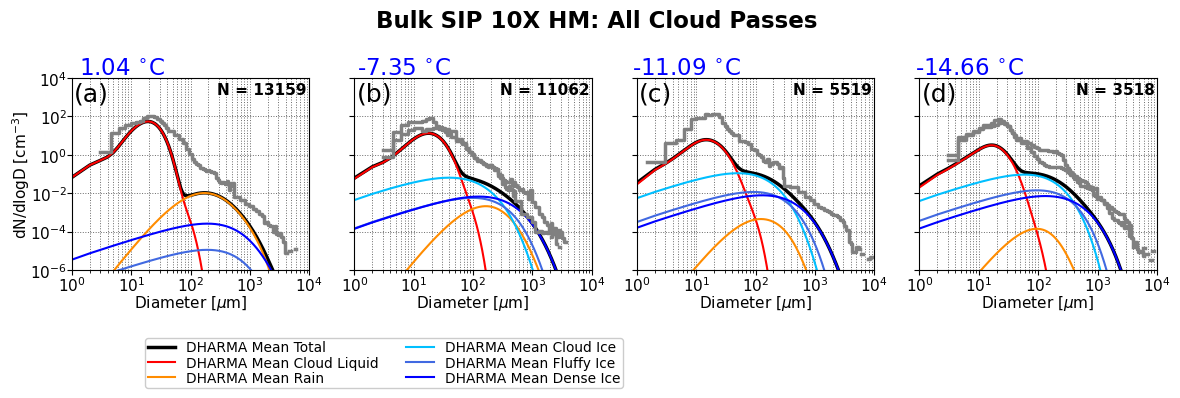

done


In [21]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3.))
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')


#========================================================
# All CPs (Loop)
#========================================================
dumi=0
for key in all_cp_dNdlogD_dict.keys():
    print(key)
    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                             c='grey', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    dNdlogD_arr = all_cp_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr,axis=0)
    
    dNdlogD_cloud_arr = all_cp_dNdlogD_cloud_dict[key]
    mean_dNdlogD_cloud = np.mean(dNdlogD_cloud_arr,axis=0)
    
    dNdlogD_rain_arr = all_cp_dNdlogD_rain_dict[key]
    mean_dNdlogD_rain = np.mean(dNdlogD_rain_arr,axis=0)    

    dNdlogD_cloud_ice_arr = all_cp_dNdlogD_cloud_ice_dict[key]
    mean_dNdlogD_cloud_ice = np.mean(dNdlogD_cloud_ice_arr,axis=0)   

    dNdlogD_fluffy_ice_arr = all_cp_dNdlogD_fluffy_ice_dict[key]
    mean_dNdlogD_fluffy_ice = np.mean(dNdlogD_fluffy_ice_arr,axis=0)

    dNdlogD_dense_ice_arr = all_cp_dNdlogD_dense_ice_dict[key]
    mean_dNdlogD_dense_ice = np.mean(dNdlogD_dense_ice_arr,axis=0) 
    
    num_dsds = len(dNdlogD_arr[:,0])
   # for ii in range(num_dsds):
   #    if ii == 0.:
   #         axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25,label='DHARMA')
   #     else:
   #         axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25)
            
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD,c='black',lw=2.5,label='DHARMA Mean Total')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_cloud,c='red',lw=1.5,label='DHARMA Mean Cloud Liquid')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_rain,c='darkorange',lw=1.5,label='DHARMA Mean Rain')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_cloud_ice,c='deepskyblue',lw=1.5,label='DHARMA Mean Cloud Ice')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_fluffy_ice,c='royalblue',lw=1.5,label='DHARMA Mean Fluffy Ice')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_dense_ice,c='blue',lw=1.5,label='DHARMA Mean Dense Ice')



    dum_str = 'N = '+str(int(num_dsds))
    axes_flat[dumi].text(0.99,0.98,dum_str,fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat[dumi].transAxes)

    dumi+=1  


for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(2.35,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[1:], labels[1:], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(2.35, -0.65), labelspacing=0.1, 
                    borderpad=0.2, ncol=2)

plt.suptitle(title_sim_name+': All Cloud Passes',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# Updrafts Only, all species

lj_pos1
lj_neg7
p3_neg11
lj_neg15


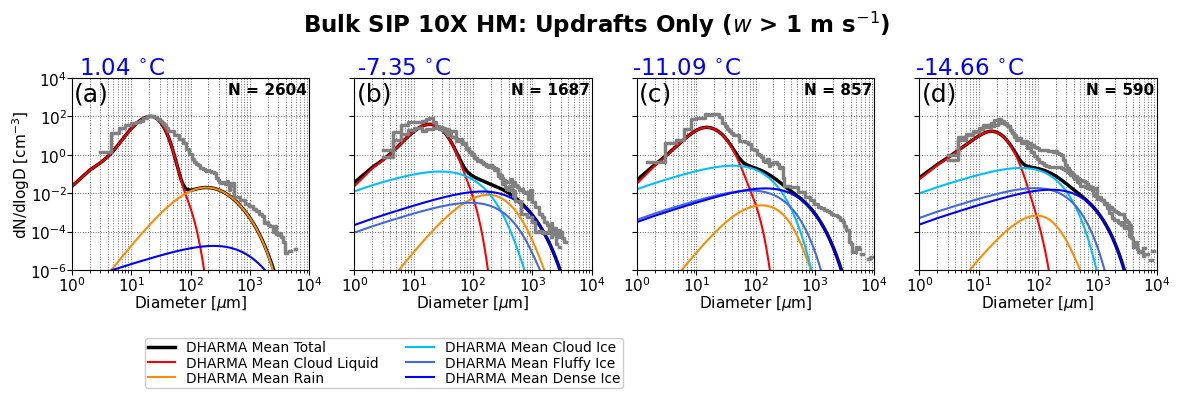

done


In [22]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3.))
axes_flat = np.ndarray.flatten(axes)
Fontsize=11

for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)

dum_ticks = np.arange(0,5,1)
xticks = ['10$^{'+str(int(t))+'}$' for t in dum_ticks]
for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)

labs = ['('+chr(ord('a')+i)+')' for i in range(n_obs)]
for dumi,ax in enumerate(axes_flat):
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')


#========================================================
# Updraft CPs (Loop)
#========================================================
dumi=0
for key in up_w_dNdlogD_dict.keys():
    print(key)
    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                             c='grey', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    dNdlogD_arr = up_w_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr,axis=0)
    
    dNdlogD_cloud_arr = up_w_dNdlogD_cloud_dict[key]
    mean_dNdlogD_cloud = np.mean(dNdlogD_cloud_arr,axis=0)
    
    dNdlogD_rain_arr = up_w_dNdlogD_rain_dict[key]
    mean_dNdlogD_rain = np.mean(dNdlogD_rain_arr,axis=0)    

    dNdlogD_cloud_ice_arr = up_w_dNdlogD_cloud_ice_dict[key]
    mean_dNdlogD_cloud_ice = np.mean(dNdlogD_cloud_ice_arr,axis=0)   

    dNdlogD_fluffy_ice_arr = up_w_dNdlogD_fluffy_ice_dict[key]
    mean_dNdlogD_fluffy_ice = np.mean(dNdlogD_fluffy_ice_arr,axis=0)

    dNdlogD_dense_ice_arr = up_w_dNdlogD_dense_ice_dict[key]
    mean_dNdlogD_dense_ice = np.mean(dNdlogD_dense_ice_arr,axis=0) 
    
    num_dsds = len(dNdlogD_arr[:,0])
   # for ii in range(num_dsds):
   #    if ii == 0.:
   #         axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25,label='DHARMA')
   #     else:
   #         axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25)
            
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD,c='black',lw=2.5,label='DHARMA Mean Total')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_cloud,c='red',lw=1.5,label='DHARMA Mean Cloud Liquid')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_rain,c='darkorange',lw=1.5,label='DHARMA Mean Rain')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_cloud_ice,c='deepskyblue',lw=1.5,label='DHARMA Mean Cloud Ice')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_fluffy_ice,c='royalblue',lw=1.5,label='DHARMA Mean Fluffy Ice')
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD_dense_ice,c='blue',lw=1.5,label='DHARMA Mean Dense Ice')



    dum_str = 'N = '+str(int(num_dsds))
    axes_flat[dumi].text(0.99,0.98,dum_str,fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat[dumi].transAxes)

    dumi+=1  


for ii in range(n_obs):
    dumstr = str(np.around(target_obs_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')

#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(2.35,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

# =========================================================
# LEGEND CREATION (THE FIX IS HERE)
# =========================================================
# Get all the handles and labels from the first subplot
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[1:], labels[1:], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(2.35, -0.65), labelspacing=0.1, 
                    borderpad=0.2, ncol=2)

plt.suptitle(title_sim_name+': Updrafts Only ($w$ > 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')
plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)

save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# All CPs, no dynamical conditioning, only total PSD

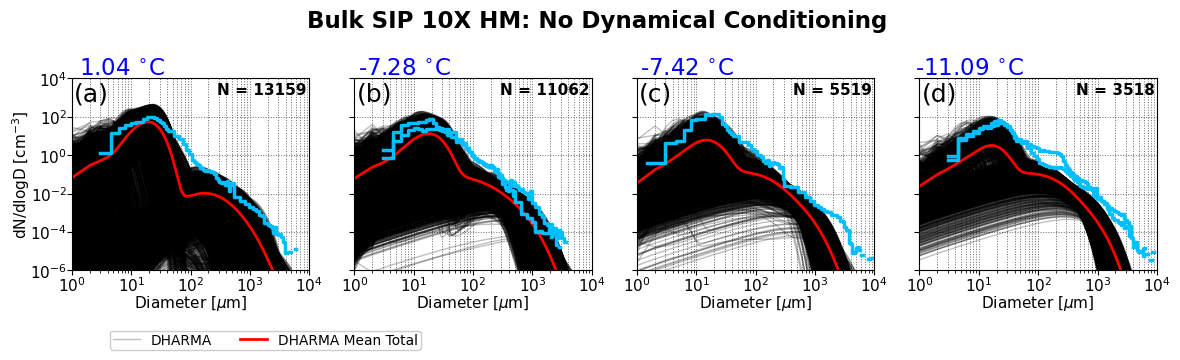

done


In [23]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3),constrained_layout=False)
axes_flat = np.ndarray.flatten(axes)
Fontsize=11


for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])


#left_axes = [axes_flat_1[0],axes_flat_1[1],axes_flat_1[2],axes_flat_1[3]]
left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = []
for dum_tick in dum_ticks:
    yticks.append('10$^{'+str(int(dum_tick))+'}$')
    
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)
    
dum_ticks = np.arange(0,5,1)
xticks = []
for dum_tick in dum_ticks:
    xticks.append('10$^{'+str(int(dum_tick))+'}$')

for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)  
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)
    
labs = ['(a)','(b)','(c)','(d)']
dumi=0
for ax in axes_flat:
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')
    dumi+=1
    

#========================================================
# All CPs (Loop)
#========================================================
dumi=0
for key in all_cp_dNdlogD_dict.keys():

    dNdlogD_arr = all_cp_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr,axis=0)
    
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        if ii == 0.:
            axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25,label='DHARMA')
        else:
            axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25)
            
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD,c='red',lw=2.,label='DHARMA Mean Total')


    dum_str = 'N = '+str(int(num_dsds))
    axes_flat[dumi].text(0.99,0.98,dum_str,fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    dumi+=1  
    
    
for ii in range(n_obs):
    dumstr = str(np.around(obs_mean_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')


#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[:-1], labels[:-1], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

plt.suptitle(title_sim_name+': No Dynamical Conditioning',fontsize=Fontsize*1.5,fontweight='bold')

plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)


save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# Updrafts only, only total PSD

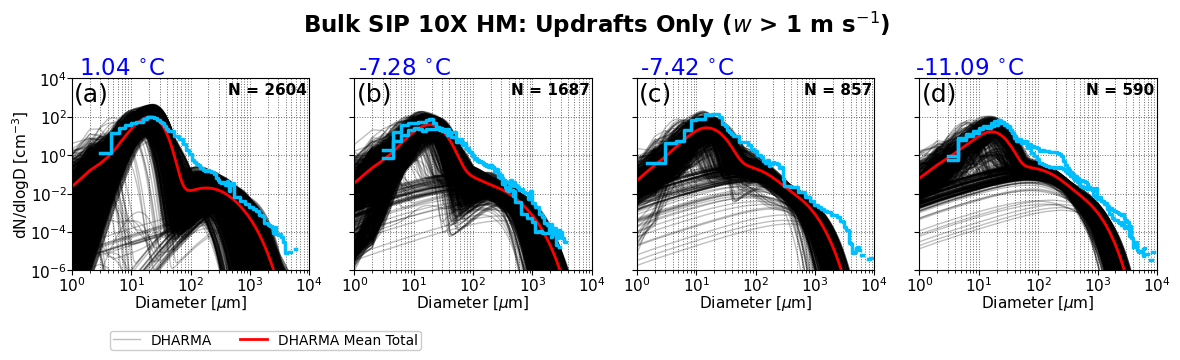

done


In [24]:
n_obs = len(target_keys)
fig,axes = plt.subplots(nrows=1,ncols=n_obs,figsize=(3.5*n_obs, 3),constrained_layout=False)
axes_flat = np.ndarray.flatten(axes)
Fontsize=11


for ax in axes_flat:
    ax.grid(which='both',lw=0.7,ls='dotted',c='dimgrey')
    ax.tick_params(labelsize=Fontsize,pad=0)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylim(1.e-6,1.e4)
    ax.set_xlim(1,5000)
    ax.set_yticks(10.**(np.arange(-6,6,2)))
    ax.set_xticks(10.**(np.arange(0,3,1)))
    ax.set_xticklabels([])
    ax.set_yticklabels([])


#left_axes = [axes_flat_1[0],axes_flat_1[1],axes_flat_1[2],axes_flat_1[3]]
left_axes = [axes_flat[0]]
dum_ticks = np.arange(-6,6,2)
yticks = []
for dum_tick in dum_ticks:
    yticks.append('10$^{'+str(int(dum_tick))+'}$')
    
for ax in left_axes:
    ax.set_yticklabels(yticks)
    ax.set_ylabel('dN/dlogD [cm$^{-3}$]',fontsize=Fontsize,labelpad=-1)
    
dum_ticks = np.arange(0,5,1)
xticks = []
for dum_tick in dum_ticks:
    xticks.append('10$^{'+str(int(dum_tick))+'}$')

for ax in axes:
    ax.set_xlabel('Diameter [$\\mu$m]',fontsize=Fontsize,labelpad=-0.15)  
    ax.set_xticks(10**dum_ticks)
    ax.set_xticklabels(xticks)
    
labs = ['(a)','(b)','(c)','(d)']
dumi=0
for ax in axes_flat:
    ax.text(0.01,0.98,labs[dumi],transform=ax.transAxes,fontsize=Fontsize*1.65,ha='left',va='top')
    dumi+=1
    

#========================================================
# All CPs (Loop)
#========================================================
dumi=0
for key in up_w_dNdlogD_dict.keys():

    dNdlogD_arr = up_w_dNdlogD_dict[key]
    mean_dNdlogD = np.mean(dNdlogD_arr,axis=0)
    
    num_dsds = len(dNdlogD_arr[:,0])
    for ii in range(num_dsds):
        if ii == 0.:
            axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25,label='DHARMA')
        else:
            axes_flat[dumi].plot(diam_midbins*1.e6,dNdlogD_arr[ii,:],c='k',lw=1,alpha=0.25)
            
    axes_flat[dumi].plot(diam_midbins*1.e6,mean_dNdlogD,c='red',lw=2.,label='DHARMA Mean Total')


    dum_str = 'N = '+str(int(num_dsds))
    axes_flat[dumi].text(0.99,0.98,dum_str,fontsize=Fontsize,fontweight='bold',ha='right',va='top',transform=axes_flat[dumi].transAxes)

    # Plot observed
    for obs_key in obs_cp_dict.keys():
        obs_key_split = obs_key.split('_')
        if (obs_key_split[0] in key) and (obs_key_split[2] in key):
            _obs_src = obs_cp_dict[obs_key]
            axes_flat[dumi].step(_obs_src['diam'], _obs_src['dNdlogD'],
                         c='deepskyblue', lw=2.5, label='In Situ', where='mid', zorder=1000)
    
    dumi+=1  
    
    
for ii in range(n_obs):
    dumstr = str(np.around(obs_mean_temps[ii],2))+' $^{\\circ}$C'
    axes_flat[ii].text(0.21,1.05,dumstr,transform=axes_flat[ii].transAxes,fontsize=Fontsize*1.5,c='blue',ha='center',va='center')


#axes_flat[0].legend(loc='lower right',framealpha=True,fontsize=Fontsize*0.9,bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)
handles, labels = axes_flat[0].get_legend_handles_labels()

# Create the legend, but skip the first handle and label ('In Situ')
# by slicing the lists from the second element onwards.
axes_flat[0].legend(handles[:-1], labels[:-1], 
                    loc='lower right', framealpha=True, fontsize=Fontsize*0.9,
                    bbox_to_anchor=(1.5,-0.45),labelspacing=0.1,borderpad=0.2,ncol=2)

plt.suptitle(title_sim_name+': Updrafts Only ($w$ > 1 m s$^{-1}$)',fontsize=Fontsize*1.5,fontweight='bold')

plt.subplots_adjust(wspace=0.19,hspace=0.09,top=0.75)


save_path = '/discover/nobackup/mwstanfo/figures/camp2ex_paper/'
outfile = 'fig_bulk_cloud_pass_DSDs_cumulatively_integrated_Reff_Veff_Nd.png'
#plt.savefig(save_path+outfile,dpi=200,bbox_inches='tight')
plt.show()
plt.close()
print('done')

In [25]:
sim_dict = {}
for key in up_w_dNdlogD_dict.keys():
    sim_dict[key] = {}
    sim_dict[key] = {'up_w_dNdlogD':up_w_dNdlogD_dict[key],\
                     'up_w_dNdlogD_cloud':up_w_dNdlogD_cloud_dict[key],\
                     'up_w_dNdlogD_rain':up_w_dNdlogD_rain_dict[key],\
                     'up_w_dNdlogD_cloud_ice':up_w_dNdlogD_cloud_ice_dict[key],\
                     'up_w_dNdlogD_fluffy_ice':up_w_dNdlogD_fluffy_ice_dict[key],\
                     'up_w_dNdlogD_dense_ice':up_w_dNdlogD_dense_ice_dict[key],\
                     'up_w_dNdD':up_w_dNdlogD_dict[key],\
                     'up_w_dNdD_cloud':up_w_dNdD_cloud_dict[key],\
                     'up_w_dNdD_rain':up_w_dNdD_rain_dict[key],\
                     'up_w_dNdD_cloud_ice':up_w_dNdD_cloud_ice_dict[key],\
                     'up_w_dNdD_fluffy_ice':up_w_dNdD_fluffy_ice_dict[key],\
                     'up_w_dNdD_dense_ice':up_w_dNdD_dense_ice_dict[key],\
                     'all_cp_dNdlogD':all_cp_dNdlogD_dict[key],\
                     'all_cp_dNdlogD_cloud':all_cp_dNdlogD_cloud_dict[key],\
                     'all_cp_dNdlogD_rain':all_cp_dNdlogD_rain_dict[key],\
                     'all_cp_dNdlogD_cloud_ice':all_cp_dNdlogD_cloud_ice_dict[key],\
                     'all_cp_dNdlogD_fluffy_ice':all_cp_dNdlogD_fluffy_ice_dict[key],\
                     'all_cp_dNdlogD_dense_ice':all_cp_dNdlogD_dense_ice_dict[key],\
                     'all_cp_dNdD':all_cp_dNdlogD_dict[key],\
                     'all_cp_dNdD_cloud':all_cp_dNdD_cloud_dict[key],\
                     'all_cp_dNdD_rain':all_cp_dNdD_rain_dict[key],\
                     'all_cp_dNdD_cloud_ice':all_cp_dNdD_cloud_ice_dict[key],\
                     'all_cp_dNdD_fluffy_ice':all_cp_dNdD_fluffy_ice_dict[key],\
                     'all_cp_dNdD_dense_ice':all_cp_dNdD_dense_ice_dict[key],\
                     'diam_tot':diam_midbins*1.e6,\
                    }

In [26]:
for key,val in sim_dict.items():
    print(key)
    for key2,val2 in val.items():
        print('     ',key2,np.shape(val2))

lj_pos1
      up_w_dNdlogD (2604, 5000)
      up_w_dNdlogD_cloud (2604, 5000)
      up_w_dNdlogD_rain (2604, 5000)
      up_w_dNdlogD_cloud_ice (2604, 5000)
      up_w_dNdlogD_fluffy_ice (2604, 5000)
      up_w_dNdlogD_dense_ice (2604, 5000)
      up_w_dNdD (2604, 5000)
      up_w_dNdD_cloud (2604, 5000)
      up_w_dNdD_rain (2604, 5000)
      up_w_dNdD_cloud_ice (2604, 5000)
      up_w_dNdD_fluffy_ice (2604, 5000)
      up_w_dNdD_dense_ice (2604, 5000)
      all_cp_dNdlogD (13159, 5000)
      all_cp_dNdlogD_cloud (13159, 5000)
      all_cp_dNdlogD_rain (13159, 5000)
      all_cp_dNdlogD_cloud_ice (13159, 5000)
      all_cp_dNdlogD_fluffy_ice (13159, 5000)
      all_cp_dNdlogD_dense_ice (13159, 5000)
      all_cp_dNdD (13159, 5000)
      all_cp_dNdD_cloud (13159, 5000)
      all_cp_dNdD_rain (13159, 5000)
      all_cp_dNdD_cloud_ice (13159, 5000)
      all_cp_dNdD_fluffy_ice (13159, 5000)
      all_cp_dNdD_dense_ice (13159, 5000)
      diam_tot (5000,)
lj_neg7
      up_w_dNdlogD (1687,

In [28]:
save_path = '/pscratch/sd/m/mckenna/dharma_post/'
file_name = save_path+sim_name+'_cloud_pass_dict_with_1degC.p'
pickle.dump(sim_dict,open(file_name,"wb")) 